In [1]:
import sympy as sp

from einsteinpy.symbolic import (
    MetricTensor,
    ChristoffelSymbols,
    RiemannCurvatureTensor,
    RicciTensor,
    RicciScalar,
    EinsteinTensor,
)
from IPython.display import display, Math, Latex

sp.init_printing()

In [2]:
t, r, theta, phi = sp.symbols("t r θ φ")
M = sp.symbols("M", positive=True)

coords = (t, r, theta, phi)

names = ["t", "r", "θ", "φ"]

Phi = sp.Function("Phi")(r,t)
Lam = sp.Function("Lambda")(r,t)

In [3]:
f1 = -sp.exp(2*Phi)
f2 = sp.exp(2*Lam)
metric = [
    [f1,       0,      0,                    0],
    [0,      f2,     0,                    0],
    [0,       0,      r**2,                 0],
    [0,       0,      0,      r**2 * sp.sin(theta)**2],
]

g = MetricTensor(metric, coords)

g.tensor()

⎡  2⋅Φ(r, t)                            ⎤
⎢-ℯ               0       0       0     ⎥
⎢                                       ⎥
⎢              2⋅Λ(r, t)                ⎥
⎢     0       ℯ           0       0     ⎥
⎢                                       ⎥
⎢                          2            ⎥
⎢     0           0       r       0     ⎥
⎢                                       ⎥
⎢                              2    2   ⎥
⎣     0           0       0   r ⋅sin (θ)⎦

In [4]:
Gamma = ChristoffelSymbols.from_metric(g)
Gamma_arr = Gamma.tensor()


Riem = RiemannCurvatureTensor.from_metric(g)
Riem_arr = Riem.tensor()


Ric = RicciTensor.from_metric(g)
Ric_arr = Ric.tensor()

Ric_simplified = sp.Array([
    [sp.simplify(Ric_arr[i, j]) for j in range(4)]
    for i in range(4)
])


R_scalar = RicciScalar.from_metric(g)

sp.simplify(R_scalar.expr)


Ein = EinsteinTensor.from_metric(g)
Ein_arr = Ein.tensor()

Ein_simplified = sp.Array([
    [sp.simplify(Ein_arr[i, j]) for j in range(4)]
    for i in range(4)
])


In [5]:
def display_nonzero_christoffels(Gamma_arr, names):
    for mu in range(4):
        for nu in range(4):
            for rho in range(4):
                val = sp.simplify(Gamma_arr[mu, nu, rho])
                if val != 0:
                    latex_expr = (
                        r"\Gamma^{"
                        + names[mu]
                        + r"}{}_{"
                        + names[nu]
                        + r"\,"
                        + names[rho]
                        + r"} = "
                        + sp.latex(val)
                    )
                    display(Math(latex_expr))

def display_riemann_component(Riem_arr, names, alpha, beta, gamma, delta):
    """
    Display one Riemann tensor component R^alpha_{beta gamma delta}.
    """
    val = sp.simplify(Riem_arr[alpha, beta, gamma, delta])

    latex_expr = (
        r"R^{"
        + names[alpha]
        + r"}{}_{"
        + names[beta]
        + r"\,"
        + names[gamma]
        + r"\,"
        + names[delta]
        + r"} = "
        + sp.latex(val)
    )

    display(Math(latex_expr))


def display_rank2_tensor(tensor_arr, names, symbol=r"T"):

    dim = len(names)

    tensor_matrix = sp.Matrix([
        [sp.simplify(tensor_arr[i, j]) for j in range(dim)]
        for i in range(dim)
    ])

    display(Math(symbol + r"_{\mu\nu} = " + sp.latex(tensor_matrix)))


def display_scalar(expr, symbol=r"S"):
    """
    Display a scalar expression in LaTeX.
    """
    display(Math(symbol + r" = " + sp.latex(sp.simplify(expr))))

In [6]:
display_nonzero_christoffels(Gamma_arr, names)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
display_rank2_tensor(Ric_arr, names, symbol=r"R")

<IPython.core.display.Math object>

In [8]:
display_scalar(R_scalar.expr, symbol=r"R")

<IPython.core.display.Math object>

In [9]:
display_rank2_tensor(Ein_arr, names, symbol=r"G")

<IPython.core.display.Math object>

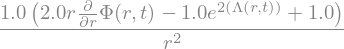

In [10]:
Ein_simplified[1][1]